# FAIRyMAGs (v0.4, 0.5) + MGnify + Magneto + nf-core, Ref

## Add output form this workflow: https://usegalaxy.eu/u/paulzierep/w/drep-fairymags-benchmark
## Example History: https://usegalaxy.eu/u/paulzierep/h/drep-fairymags-benchmark-1

In [1]:
#!/usr/bin/env python3

from bioblend.galaxy import GalaxyInstance
import pandas as pd
import io
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# === CONFIGURATION ===
load_dotenv(dotenv_path="../.env")

GALAXY_URL = "https://usegalaxy.eu"
API_KEY = os.getenv("GALAXY_API")

if not API_KEY:
    sys.exit("❌ GALAXY_API environment variable not set")

In [2]:
# Optional: output directory
OUTPUT_DIR = Path("input-v2")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Connect to Galaxy ---
gi = GalaxyInstance(url=GALAXY_URL, key=API_KEY)


def download_dataset_as_df(dataset_id, name, sep=None, save=True):
    """
    Download a Galaxy dataset and return as pandas DataFrame.
    
    Parameters:
        dataset_id (str): Galaxy dataset ID
        name (str): Name for saving file
        sep (str): Separator (None = auto-detect CSV/TSV)
        save (bool): Save file locally
    
    Returns:
        pd.DataFrame
    """
    print(f"⬇️ Downloading dataset: {name} ({dataset_id})")

    content = gi.datasets.download_dataset(
        dataset_id,
        use_default_filename=False
    )

    buffer = io.BytesIO(content)

    # Try parsing
    if sep:
        df = pd.read_csv(buffer, sep=sep, comment="#")
    else:
        try:
            df = pd.read_csv(buffer, comment="#")
        except Exception:
            buffer.seek(0)
            df = pd.read_csv(buffer, sep="\t", comment="#")

    print(f"✅ Loaded {name} with shape {df.shape}")

    # Save locally
    if save:
        out_file = OUTPUT_DIR / f"{name}.tsv"
        df.to_csv(out_file, sep="\t", index=False)
        print(f"💾 Saved to {out_file}")

    return df


###################
# Load datasets
###################

cdb_95 = download_dataset_as_df(
    dataset_id="26c75dcccb616ac832a7605e7bbe53db",
    name="cdb_clusters_95"
)

checkm2 = download_dataset_as_df(
    dataset_id="26c75dcccb616ac8789140a3bdae803a",
    name="checkm2",
    sep="\t"
)

###################
# Preview
###################

print("\n--- CDB preview ---")
print(cdb_95.head())

print("\n--- CheckM2 preview ---")
print(checkm2.head())

⬇️ Downloading dataset: cdb_clusters_95 (26c75dcccb616ac832a7605e7bbe53db)
✅ Loaded cdb_clusters_95 with shape (1224, 6)
💾 Saved to input-v2/cdb_clusters_95.tsv
⬇️ Downloading dataset: checkm2 (26c75dcccb616ac8789140a3bdae803a)
✅ Loaded checkm2 with shape (1544, 14)
💾 Saved to input-v2/checkm2.tsv

--- CDB preview ---
                                              genome secondary_cluster  \
0       RNODE_577_length_7056_cov_38.11425_ref.fasta               1_0   
1       RNODE_578_length_7436_cov_10.94682_ref.fasta               2_0   
2                       1041930.PRJNA73221_ref.fasta               3_0   
3                      1120985.PRJNA188816_ref.fasta               4_0   
4  Leptodontidium_orchidicola_MPI-SW4-AT-0643.con...               5_0   

   threshold cluster_method comparison_algorithm  primary_cluster  
0       0.05        average                ANImf                1  
1       0.05        average                ANImf                2  
2       0.05        average    

In [3]:
MIN_COMPLETENESS = 75
MAX_CONTAMINATION = 25

hq_genomes = checkm2.loc[
    (checkm2["Completeness"] >= MIN_COMPLETENESS) &
    (checkm2["Contamination"] <= MAX_CONTAMINATION),
    "Name"
].unique()

print(f"✅ High-quality genomes: {len(hq_genomes)}")

✅ High-quality genomes: 717


In [4]:
cdb_95["genome"] = cdb_95["genome"].str.replace(r"\.fasta$", "", regex=True)
cdb_95

,genome,secondary_cluster,threshold,cluster_method,comparison_algorithm,primary_cluster
0,RNODE_577_length_7056_cov_38.11425_ref,1_0,0.05,average,ANImf,1
1,RNODE_578_length_7436_cov_10.94682_ref,2_0,0.05,average,ANImf,2
2,1041930.PRJNA73221_ref,3_0,0.05,average,ANImf,3
3,1120985.PRJNA188816_ref,4_0,0.05,average,ANImf,4
4,Leptodontidium_orchidicola_MPI-SW4-AT-0643.con...,5_0,0.05,average,ANImf,5
...,...,...,...,...,...,...
1219,RNODE_63_length_9116_cov_7.17902_ref,726_0,0.05,average,ANImf,726
1220,RNODE_80_length_5133_cov_7.08687_ref,727_0,0.05,average,ANImf,727
1221,RNODE_83_length_6134_cov_3.71057_ref,728_0,0.05,average,ANImf,728
1222,RNODE_87_length_5673_cov_23.00212_ref,729_0,0.05,average,ANImf,729


In [6]:
cdb_filtered_95 = cdb_95[cdb_95["genome"].isin(hq_genomes)].copy()

print(f"✅ Filtered CDB shape: {cdb_filtered_95.shape}")
print(cdb_filtered_95.head())

✅ Filtered CDB shape: (717, 6)
                     genome secondary_cluster  threshold cluster_method  \
2    1041930.PRJNA73221_ref               3_0       0.05        average   
3   1120985.PRJNA188816_ref               4_0       0.05        average   
9   1173027.PRJNA158839_ref              10_0       0.05        average   
60  1121353.PRJNA190670_ref              44_0       0.05        average   
61   444461.PRJNA174173_ref              45_0       0.05        average   

   comparison_algorithm  primary_cluster  
2                 ANImf                3  
3                 ANImf                4  
9                 ANImf               10  
60                ANImf               44  
61                ANImf               45  


source
True Genomes        437
nf-core             123
MAGNETO              56
MGnify               36
FAIRyMAGs (v0.5)     35
FAIRyMAGs (v0.4)     30
Name: count, dtype: int64
source
True Genomes        386
FAIRyMAGs (v0.4)     30
FAIRyMAGs (v0.5)     35
MAGNETO              10
MGnify               36
nf-core              26
dtype: int64


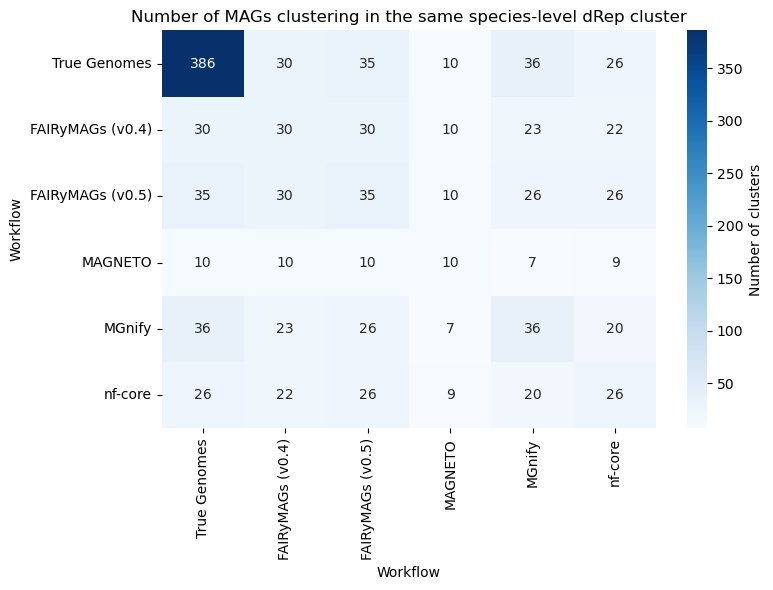

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assume df has 'genome' and 'source' columns
# If not, use your get_source() logic:
df = cdb_filtered_95.copy()  # your dataframe

def get_source(name):
    if name.endswith('_ref'):
        return 'True Genomes'
    elif '_fairymags04' in name:
        return 'FAIRyMAGs (v0.4)'
    elif '_fairymags05' in name:
        return 'FAIRyMAGs (v0.5)'
    elif '_magneto' in name:
        return 'MAGNETO'
    elif '_nfcore' in name:
        return 'nf-core'
    elif '_mgnify' in name:
        return 'MGnify'
    else:
        return 'other'

df['source'] = df['genome'].apply(get_source)

# Number of genomes per group
print(df['source'].value_counts())

# Step 1: Count genomes per cluster per source
per_cluster = df.groupby(['secondary_cluster', 'source']).size().unstack(fill_value=0)

# Step 2: Convert to boolean presence (1 if at least one genome)
presence = per_cluster[['True Genomes', 'FAIRyMAGs (v0.4)', 'FAIRyMAGs (v0.5)', 'MAGNETO', 'MGnify', 'nf-core']] > 0

# Number of dereplicated genomes per group
print(presence.sum())

# Step 3: Initialize empty overlap matrix
sources = presence.columns
overlap_matrix = pd.DataFrame(0, index=sources, columns=sources)

# Step 4: Count number of clusters shared between each pair
for i in sources:
    for j in sources:
        overlap_matrix.loc[i, j] = ((presence[i]) & (presence[j])).sum()

# Step 5: Plot heatmap
# Mask ONLY the upper triangle (exclude diagonal)
mask = np.triu(np.ones_like(overlap_matrix, dtype=bool), k=1)

plt.figure(figsize=(8,6))
sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    # mask=mask,
    cbar_kws={'label': 'Number of clusters'}
)

plt.title('Number of MAGs clustering in the same species-level dRep cluster')
plt.ylabel('Workflow')
plt.xlabel('Workflow')

plt.tight_layout()
plt.savefig("plots-v2/heatmap_mags_benchmark.svg", dpi=600, bbox_inches="tight")
plt.savefig("plots-v2/heatmap_mags_benchmark.png", dpi=600, bbox_inches="tight")
plt.show()


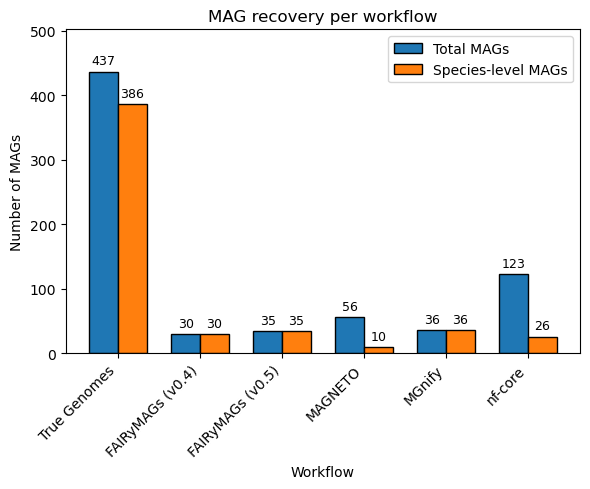

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
counts = df['source'].value_counts()
cluster_counts = presence.sum()

# Ensure consistent order
order = ['True Genomes', 'FAIRyMAGs (v0.4)', 'FAIRyMAGs (v0.5)', 'MAGNETO', 'MGnify', 'nf-core']
counts = counts.reindex(order)
cluster_counts = cluster_counts.reindex(order)

# --- Set positions ---
x = np.arange(len(order))
width = 0.35

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 5))

bars1 = ax.bar(x - width/2, counts, width, label="Total MAGs", edgecolor='black')
bars2 = ax.bar(x + width/2, cluster_counts, width, label="Species-level MAGs", edgecolor='black')

# --- Add value labels ---
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)

# --- Fix clipping (add headroom) ---
max_val = max(counts.max(), cluster_counts.max())
ax.set_ylim(0, max_val * 1.15)

# --- Labels & styling ---
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha='right')
ax.set_ylabel("Number of MAGs")
ax.set_xlabel("Workflow")
ax.set_title("MAG recovery per workflow")
ax.legend()

plt.tight_layout()

# --- Save ---
plt.savefig("plots-v2/mags_grouped_bar_with_values.svg", dpi=600, bbox_inches="tight")
plt.savefig("plots-v2/mags_grouped_bar_with_values.png", dpi=600, bbox_inches="tight")

plt.show()

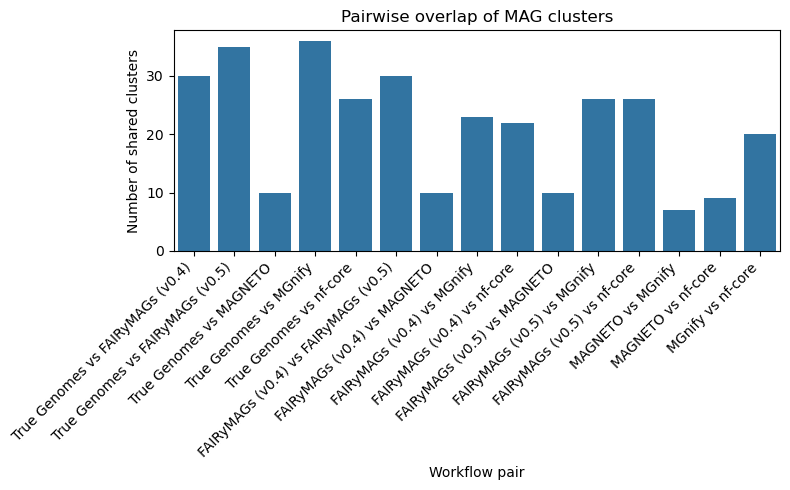

In [9]:
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

pairs = []

sources = overlap_matrix.columns

for i, j in itertools.combinations(sources, 2):
    pairs.append({
        "pair": f"{i} vs {j}",
        "overlap": overlap_matrix.loc[i, j]
    })

pairs_df = pd.DataFrame(pairs)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=pairs_df, x="pair", y="overlap")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of shared clusters")
plt.xlabel("Workflow pair")
plt.title("Pairwise overlap of MAG clusters")
plt.tight_layout()
plt.show()

In [ ]:
# Identify clusters that contain at least one true genome
ref_clusters = presence[presence['True Genomes']].index

results = []

for source in ['FAIRyMAGs', 'MAGNETO', 'MGnify']:
    
    # Clusters where this workflow has MAGs
    pred_clusters = presence[presence[source]].index
    
    # True Positives: predicted clusters that match reference clusters
    tp = len(set(pred_clusters) & set(ref_clusters))
    
    # False Positives: predicted clusters without reference
    fp = len(set(pred_clusters) - set(ref_clusters))
    
    # False Negatives: reference clusters not recovered
    fn = len(set(ref_clusters) - set(pred_clusters))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    results.append({
        "source": source,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall
    })

metrics_df = pd.DataFrame(results)

print("\n=== Precision / Recall per workflow ===")
print(metrics_df)


=== Precision / Recall per workflow ===
      source  TP  FP   FN  precision    recall
0  FAIRyMAGs  30   0  355        1.0  0.077922
1    MAGNETO  10   0  375        1.0  0.025974
2     MGnify  36   0  349        1.0  0.093506


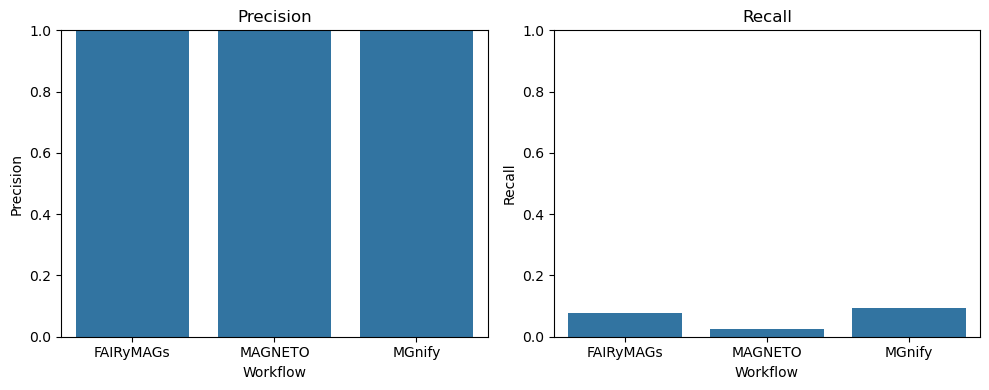

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Precision plot ---
sns.barplot(
    data=metrics_df,
    x="source",
    y="precision",
    ax=axes[0]
)
axes[0].set_title("Precision")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("Workflow")

# --- Recall plot ---
sns.barplot(
    data=metrics_df,
    x="source",
    y="recall",
    ax=axes[1]
)
axes[1].set_title("Recall")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Recall")
axes[1].set_xlabel("Workflow")

plt.tight_layout()
plt.show()

# Version 2 (+nf-core mags and fairymags 0.5)